# Chicago District Risk Classification
In this notebook, we perform an exploratory data analysis on `df_crime`, with several hypothesis testings and some statistical analysis. Additionally, as our primary goal is to train a clustering algorithm, we define our training set as occurrences that happened between 2022 and 2024 and our out-of-time sample as 2025 onward. We emphasize here on the THFT crime group.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

In [2]:
from sys import path

path.insert(0, '../modules')

import utils as f
import params_cfg as pc
import visuals

colors = pc.COLORS
gen_theft = pc.GENERAL_THFT
gen_aslt = pc.GENERAL_ASLT
census_data = pc.CENSUS_DATA

%load_ext autoreload
%autoreload 2

In [3]:
# defining the project paths
brz_path = pc.BRZ_PATH
slv_path = pc.SLV_PATH
gld_path = pc.GLD_PATH
img_path = pc.IMG_PATH
model_path = pc.MODEL_PATH

### Reading the Pre-Processed Data
We continue from the last saved crime dataset from notebook 01.

In [4]:
df_crime = pd.read_csv(f'{slv_path}/df_crime_final.csv')

df_crime['district'] = df_crime['district'].astype(str)
df_crime['date'] = pd.to_datetime(df_crime['date'])


grp_comm_district = pd.read_csv(f'{gld_path}/grp_comm_district.csv')
grp_comm_district['district'] = grp_comm_district['district'].astype(str)

display(df_crime.head())
display(grp_comm_district.head())

,id,date,arrest,domestic,district,community_area,crime_group,crime_distance,max_dist_station,avg_cm_area,...,avg_dependents,avg_per_capita_income,avg_hardship_index,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index
0,13344078,2022-01-01,0,0,22,75,ASLT,1.318397,35.117633,101.260168,...,0.402875,24286.000000,41.375000,0.008,0.132,0.150,0.108,0.403,27149.0,30
1,13462579,2022-01-01,0,1,16,15,ASLT,3.737001,30.352277,103.611609,...,0.356000,27901.500000,32.666667,0.041,0.116,0.126,0.193,0.340,24336.0,35
2,12581817,2022-01-01,1,1,4,46,ASLT,4.595490,29.875997,95.610774,...,0.416167,18437.833333,61.333333,0.047,0.298,0.197,0.266,0.411,16579.0,75
3,12583090,2022-01-01,0,0,18,8,THFT,1.561979,22.702502,99.573467,...,0.212833,57590.166667,9.000000,0.019,0.129,0.070,0.025,0.226,88669.0,1
4,12613727,2022-01-01,0,0,8,70,THFT,4.272004,28.976288,87.659475,...,0.386833,16623.416667,67.166667,0.040,0.104,0.117,0.177,0.369,23482.0,37


,district,area_count,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,avg_housing_crowded,avg_below_pvty,avg_unemployed,avg_without_hsd,avg_dependents,avg_per_capita_income,avg_hardship_index
0,1,7,69.513587,42.997660,486.595108,300.983622,0.036571,0.225000,0.112857,0.160143,0.259571,44906.285714,33.000000
1,10,6,129.112315,54.400566,774.673892,326.403393,0.074833,0.262667,0.162333,0.294000,0.345500,20979.833333,63.166667
2,11,7,109.321992,47.818497,765.253943,334.729478,0.074571,0.321429,0.176857,0.222429,0.356143,21936.285714,63.571429
3,12,10,78.080901,43.799069,780.809008,437.990695,0.053600,0.237800,0.118000,0.189600,0.285200,38318.700000,40.500000
4,14,7,86.491201,46.489343,605.438408,325.425401,0.041857,0.162000,0.083714,0.140571,0.267429,46609.857143,24.142857


## EDA

### Hypothesis Testing 1: Domestic and Arrest
**Q:** Are domestic and arrest variables statistically different within each crime group?

To answer it, we will consider our dataset on a daily basis, to compute the daily domestic rate and daily arrest rate for each group. We thus verify the normality condition for the resulting distributions to check which test statistic we must submitt our data to. Our roadmap is:

- Normality (Shapiro-Wilk)
- If normality is **true**: t-Student test; if **false**: Mann-Whitney U test

In [5]:
daily_df = pd.read_csv(f'{gld_path}/daily_crime.csv')
daily_df['date'] = pd.to_datetime(daily_df['date'])

daily_df.head()

,date,crime_group,count,domestic_count,arrest_count,domestic_rate,arrest_rate,avg_dist,avg_max_dist,avg_cm_area,avg_total_area,avg_cm_len,total_cm_len,avg_pct_housing,avg_pct_below_pvty,avg_pct_unemployed,avg_pct_without_hsd,avg_pct_dependents,avg_per_capita_income,avg_hardship_index
0,2022-01-01,ASLT,385,168,67,0.436364,0.174026,2.214930,26.237923,92.669258,758.297213,45.639562,383.255912,0.056488,0.255530,0.178899,0.216234,0.357696,24638.457143,57.311688
1,2022-01-01,THFT,271,20,11,0.073801,0.040590,2.193847,26.016693,88.588291,753.692099,45.144340,389.535137,0.044232,0.221782,0.145793,0.172653,0.320328,34800.881919,43.202952
2,2022-01-02,ASLT,192,74,27,0.385417,0.140625,2.262388,26.807018,91.957107,786.937101,45.425812,395.981936,0.055635,0.247734,0.170125,0.209823,0.352198,25608.619792,55.286458
3,2022-01-02,THFT,188,6,9,0.031915,0.047872,2.334804,26.124524,87.918836,710.439512,45.369603,370.839716,0.040973,0.205282,0.137287,0.153830,0.307612,37277.053191,37.638298
4,2022-01-03,ASLT,184,63,29,0.342391,0.157609,2.337974,27.084642,90.579649,785.944555,45.008887,397.785208,0.053946,0.257908,0.176571,0.210234,0.357386,23635.309783,56.059783


The graphics below illustrate a significant difference between the rates among crime groups. We now test if the ASLT domestic daily rate is greater, considering statistc significance, than the THFT domestic daily rate.

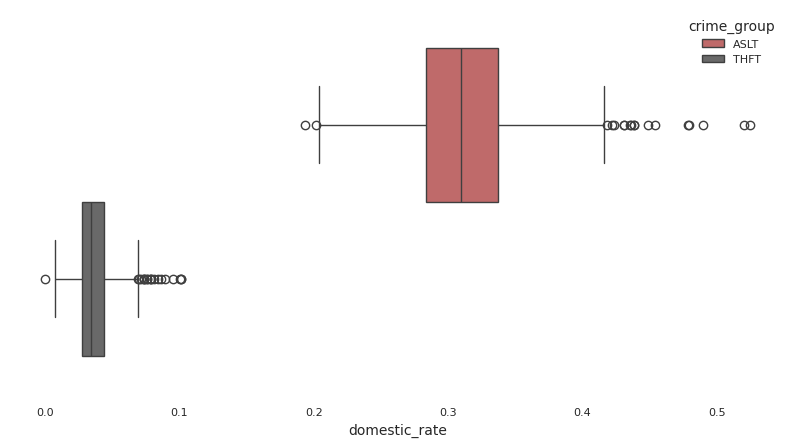

In [12]:
plt.box(False)
sns.boxplot(
    data=daily_df,
    x='domestic_rate',
    hue='crime_group',
    palette=colors
);

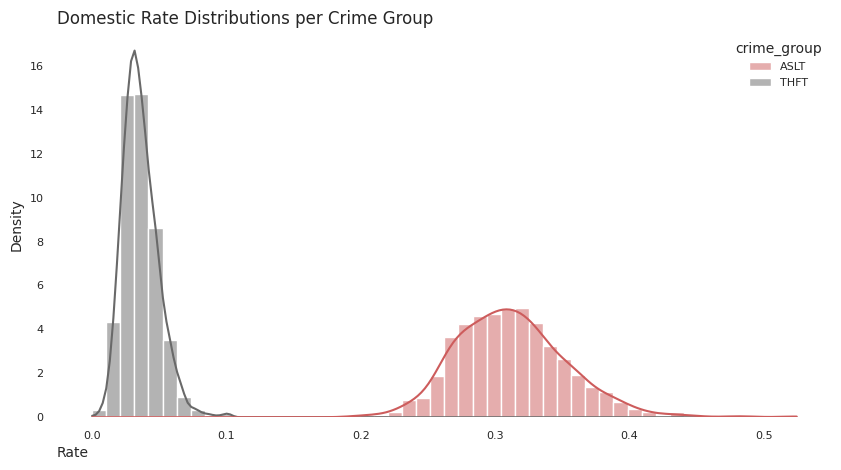

In [13]:
plt.title('Domestic Rate Distributions per Crime Group', loc='left')
plt.ylabel('Density')
plt.xlabel('Rate', loc='left')
plt.box(False)
sns.histplot(
    data=daily_df,
    x='domestic_rate',
    hue='crime_group',
    stat='density',
    kde=True,
    bins=50,
    palette=colors
);

As we have strong evidence to reject the null hypothesis, that the domestic rate daily distribution is normal, we must perform the non-parametric test: Mann-Whitney U. Its result collaborates with the graphic above, providing even stronger evidence that **the daily domestic rate for ASLT is greater than that of THFT**.

In [14]:
c = 'domestic_rate'
s_thft = daily_df.query('crime_group == "THFT"')[c].copy()
s_aslt = daily_df.query('crime_group == "ASLT"')[c].copy()

f.shapiro_test(s_thft)
print('\n')
f.shapiro_test(s_aslt)

print('\n')

f.mannwhitneyu_test(s_aslt, s_thft)

--- Shapiro-Wilk Test --- 
Statistic: 0.9600801490333336
P-value: 8.112699290648048e-18


--- Shapiro-Wilk Test --- 
Statistic: 0.9787607281836954
P-value: 1.925680645273619e-12


---  Mann-Whitney U Test --- 
Statistic: 1503076.0
P-value: 0.0


The $\chi^2$ test evaluates whether or not there is a statistically significant dependence between variables. In our case, we consider the contingency table of **total** domestic events per crime group. The test thus checks if the difference of the resulting proportions is significant.

As a result, according to this data and test, the resulting $p$-value of 0 indicates a strong dependence between domestic rate among crime group.

Observe that, in this case, we have not tested on a daily basis, but, instead, across all data. That is, instead of comparing rates per day, we are testing whether being a THFT vs ASLT crime affects the likelihood of it being domestic or resulting in arrest.

In [15]:
cont_table = pd.crosstab(df_crime['domestic'], df_crime['crime_group'])

display(cont_table)

chi2, p_value, _, _ = f.chi2_contingency(cont_table)

print(f'chi-squared statistic: {chi2}')
print(f'P-value: {p_value}')

crime_group,ASLT,THFT
domestic,,
0,264640,380162
1,120022,13949


chi-squared statistic: 104580.0530513628
P-value: 0.0


For the arrest rate, we have similar results.

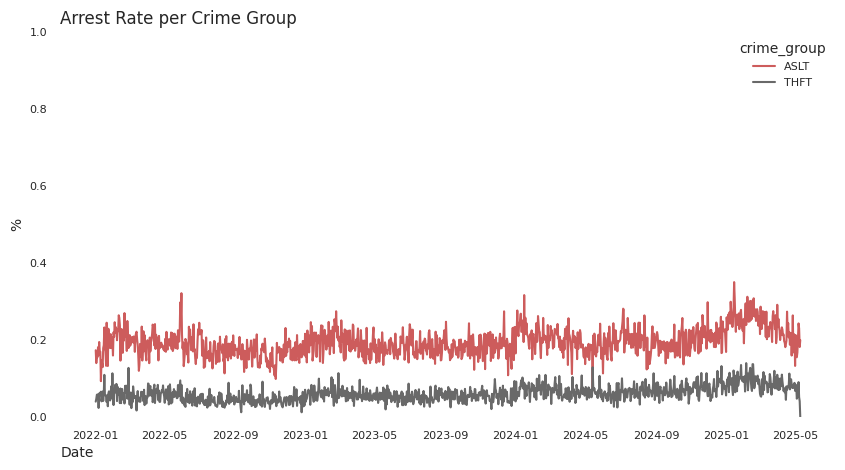

In [16]:
plt.title('Arrest Rate per Crime Group', loc='left')
plt.xlabel('Date', loc='left')
plt.ylabel('%')
plt.ylim(0, 1)
plt.box(False)
sns.lineplot(
    data=daily_df,
    x='date',
    y='arrest_rate',
    hue='crime_group',
    palette=colors
);

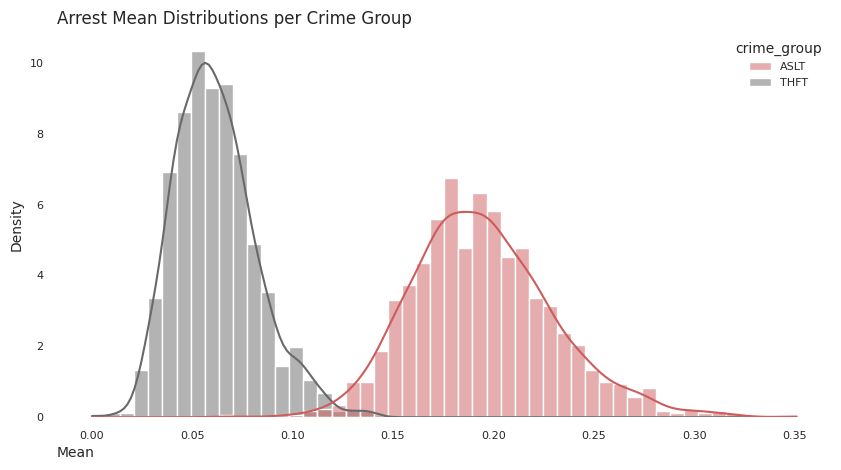

In [17]:
plt.title('Arrest Mean Distributions per Crime Group', loc='left')
plt.ylabel('Density')
plt.xlabel('Mean', loc='left')
plt.box(False)
sns.histplot(
    data=daily_df,
    x='arrest_rate',
    hue='crime_group',
    stat='density',
    kde=True,
    bins=50,
    palette=colors
);

In [18]:
c = 'arrest_rate'
s_thft = daily_df.query('crime_group == "THFT"')[c].copy()
s_aslt = daily_df.query('crime_group == "ASLT"')[c].copy()

print('THFT')
f.shapiro_test(s_thft)
print('\nASLT')
f.shapiro_test(s_aslt)

print('\n')

f.mannwhitneyu_test(s_aslt, s_thft)

THFT
--- Shapiro-Wilk Test --- 
Statistic: 0.9756840024331513
P-value: 1.6653643866420835e-13

ASLT
--- Shapiro-Wilk Test --- 
Statistic: 0.986842438038246
P-value: 4.543829101897453e-09


---  Mann-Whitney U Test --- 
Statistic: 1502177.0
P-value: 0.0


In [19]:
cont_table = pd.crosstab(df_crime['arrest'], df_crime['crime_group'])
chi2, p_value, _, _ = f.chi2_contingency(cont_table)

display(cont_table)

print(f'chi-squared statistic: {chi2}')
print(f'P-value: {p_value}')

crime_group,ASLT,THFT
arrest,,
0,310094,370149
1,74568,23962


chi-squared statistic: 31182.424635043575
P-value: 0.0


#### Hypothesis Testing: Conclusion
Therefore, the Mann-Whitney U test has shown us that the difference between crime groups is consistent day-by-day (over time), whereas the $\chi^2$ test has shown us that there is a difference overall.

Regarding our main goal, to classify districts by their criminal activity, both domestic and arrest rates can take meaningful insights, such as:

1. Domestic Rate: Proxy for Crime Severity and Social Vulnerability
    - domestic crimes can be seen as concealed crimes, since their occurrence relies indoors (hidden violence: less visible in public overall and in public data)
    - such crimes are typically more harmful, emotionally and socially, and may indicate underlying risks not being accounted for by raw counts
    - districts with a higher domestic rate may deserve a higher score, indicating that features such as *average domestic rate* may be a good candidate for separating them

2. Arrest rate: Proxy for Crime Effectiveness
    - lower arrest rates may suggest:
        - difficulty solving crimes, which may be due to lack of witness cooperation and resources
        - possible under-policing or inefficiency
        - areas where crime may persist longer (weak deterrence)
    - conversely, high arrest rates may reflect effective enforcenment, indicating that features such as *average arrest rate* may serve as an inverse risk indicator

### Crime Rate vs Crime Distance
From the scatterplot below, we see no correlation at all between `avg_crime_distance` and `arrest_rate`. Considering that both variables were calculated for a particular crime group for each day, this suggest that the outliers might be where our real interest lies. However, we have not yet considered the aggregation per district. We leave this analysis for later.

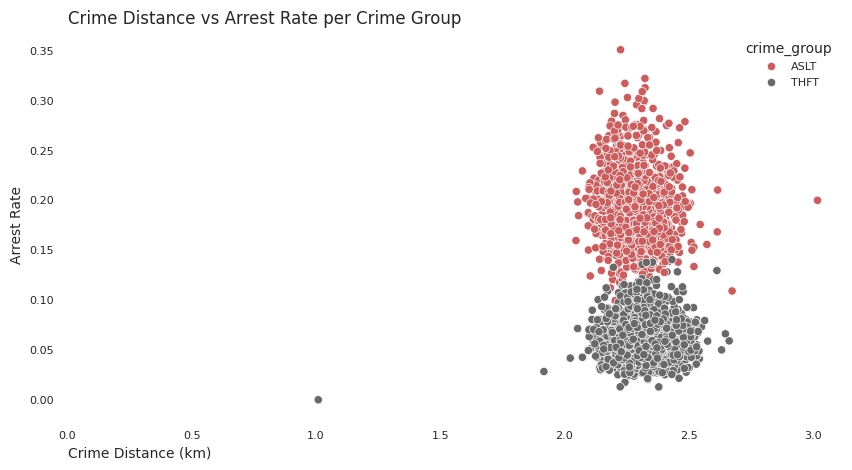

In [20]:
sns.scatterplot(
    data=daily_df,
    x='avg_dist',
    y='arrest_rate',
    hue='crime_group',
    palette=colors
)
plt.box(False)
plt.title('Crime Distance vs Arrest Rate per Crime Group', loc='left')
plt.xlabel('Crime Distance (km)', loc='left')
plt.ylabel('Arrest Rate')
plt.xlim(0);

### Hypothesis Testing 2: Number of Occurrences and Total Area Covered
**Q:** Do districts that cover larger areas have a greater number of occurrences?

In [11]:
hyp_test = df_crime[['id', 'district', 'total_cm_area']].copy()

# taking the top 50% of districts with the biggest total cm area
most_cvd_districts = grp_comm_district\
    .sort_values('total_cm_area', ascending=False)['district']\
    [:int(len(df_crime['district'].unique()) / 2) + 1]\
    .values


hyp_test = hyp_test.groupby('district')\
    .agg(
        total_crimes=('id', 'count')
    ).reset_index()

hyp_test['grp_cvd'] = hyp_test['district'].isin(most_cvd_districts)

hyp_test.head()

,district,total_crimes,grp_cvd
0,1,44203,False
1,10,32261,True
2,11,42801,False
3,12,48189,True
4,14,28119,False


In order to perform the t-test, we need to ensure that the data is normally distributed. For that, we apply Shapiro's test for each group. We obtain


| p-value | districts group |
| --- | --- |
| 43.5% | 50% top |
| 12.8% | 50% bottom |

such that we do not have suffiient evidence to reject the normality hypothesis.

In [12]:
print('50% Top Districts')
f.shapiro_test(
    hyp_test.query('grp_cvd == True')['total_crimes']
)

print('\n50% Bottom Districts')
f.shapiro_test(
    hyp_test.query('grp_cvd == False')['total_crimes']
)

50% Top Districts
--- Shapiro-Wilk Test --- 
Statistic: 0.9323519218982228
P-value: 0.4351330798211642

50% Bottom Districts
--- Shapiro-Wilk Test --- 
Statistic: 0.8872305243189973
P-value: 0.12839411096127218


#### Hypothesis Testing: Conclusion
Now for the T-test. It returns 33.6% as p-value, thus showing that **there is no statistically significant evidence that larger-area districts experience an elevated crime count**. This suggests that spatial size alone may not account for crime volume.

In [76]:
f.student_test(
    hyp_test.query('grp_cvd == True')['total_crimes'],
    hyp_test.query('grp_cvd == False')['total_crimes']
)

--- Student T-Test --- 
Statistic: 0.4289902668404811
P-value: 0.33625787199035956


### Hypothesis Testing 3: Hardship Index and Primary Types
**Q:** Is the average daily percentage of the hardship index different between ASLT and THFT?

First of all, let us understand the meaning of the hardship index. By hardship alone, we get *a condition that is difficult to endure; suffering; deprivation; oppression*, by which we conclude it must increase as measures like poverty increases and it must decrease as measures like income per capita increase. If we plot a scatterplot for these variables we can check the veracity of such claims. Hence, as ASLT encompasses more aggressive behavior, and as such, a more difficult condition to endure, it is expected the hardship index to be greater in this crime group.

By plotting `avg_hardship_index`  per `crime_group`, we note ASLT to be, in fact, greater, but it remains to be seen if such difference is statistically significant, since we have outliers from THFT in the ASLT range and vice-versa.

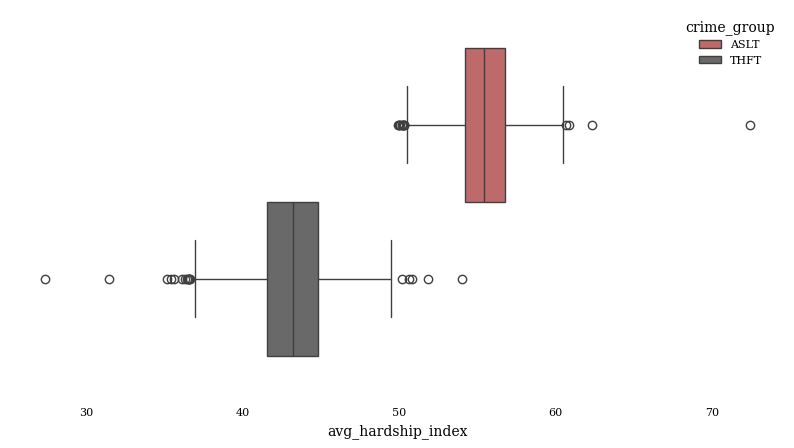

In [ ]:
plt.box(False)
sns.boxplot(
    data=daily_df,
    x='avg_hardship_index',
    hue='crime_group',
    palette=colors
);

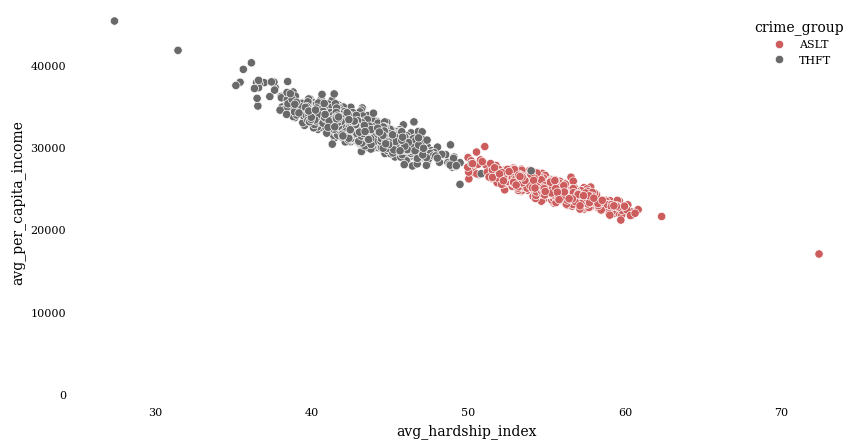

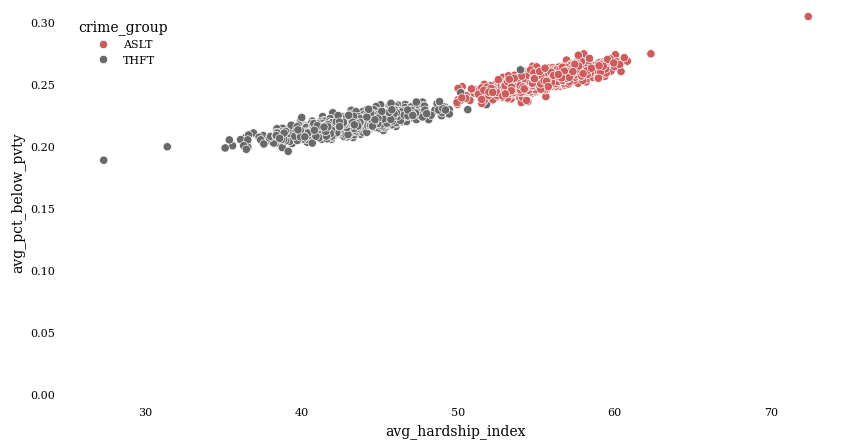

In [33]:
for c in ['avg_per_capita_income', 'avg_pct_below_pvty']:
    plt.box(False)
    sns.scatterplot(
        data=daily_df,
        x='avg_hardship_index',
        y=c,
        hue='crime_group',
        palette=colors
    );
    plt.ylim(0)
    plt.show()

As we are well aware by now, we check the normality condition for `avg_hardship_index` for each group, whence we have sufficient evidence to reject the null of normality. Therefore, a non-parametric statistical teste must be perform: Mann-Whitney U test.

In [36]:
print('Shapiro Test for ASLT hardship index')
f.shapiro_test(
    daily_df.query('crime_group == "ASLT"')['avg_hardship_index']
)

print('\nShapiro Test for TFHT hardship index')
f.shapiro_test(
    daily_df.query('crime_group == "THFT"')['avg_hardship_index']
)

Shapiro Test for ASLT hardship index
--- Shapiro-Wilk Test --- 
Statistic: 0.9765650395043229
P-value: 3.283580433239819e-13

Shapiro Test for TFHT hardship index
--- Shapiro-Wilk Test --- 
Statistic: 0.9865714155871865
P-value: 3.35872371477045e-09


#### Hypothesis Testing: Conclusion
The test returns a $p$-value of 0, yielding sufficient evidence to reject the null: according to our data, probably, the average hardship index, over community areas comprising the Chicago police districts, for the ASLT crime group is greater than that of THFT. This corroborates with the ideia that, not only ASLT crimes are more aggressive, but also occur in districts that cover poorer community areas, measured by the census data.

Together with Hypothesis Testing 1, we can conclude that the ASLT - THFT separation seems to be a good fit, as we observe statistically significant difference on crime counting, obtained via history of occurrences, and hardship index, obtained via census data.

In [37]:
f.mannwhitneyu_test(
    daily_df.query('crime_group == "ASLT"')['avg_hardship_index'],
    daily_df.query('crime_group == "THFT"')['avg_hardship_index']
)

---  Mann-Whitney U Test --- 
Statistic: 1502728.5
P-value: 0.0


### Census Data and Crime Rates: THFT
Next, we evaluate crime rates and counts with the census data. We can obtain, for instance, crime and/or rate densities (counts per square km or rate per square km).

In [6]:
thft_crime = df_crime.query('crime_group == "THFT"').copy()

grp_thft_district = thft_crime\
    .groupby('district')\
    .agg(
        crime_count=('id', 'count'),
        domestic_count=('domestic', 'sum'),
        arrest_count=('arrest', 'sum'),
        domestic_rate=('domestic', 'mean'),
        arrest_rate=('arrest', 'mean'),
        avg_dist=('crime_distance', 'mean'),
        avg_cm_area=('avg_cm_area', 'mean'),
        avg_cm_len=('avg_cm_len', 'mean'),
        total_cm_area=('total_cm_area', 'mean'),
        total_cm_len=('total_cm_len', 'mean')
    )\
    .reset_index()


grp_thft_district['crime_density'] = grp_thft_district['crime_count'] / grp_thft_district['total_cm_area']
grp_thft_district['domestic_density'] = grp_thft_district['domestic_count'] / grp_thft_district['total_cm_area']
grp_thft_district['arrest_density'] = grp_thft_district['arrest_count'] / grp_thft_district['total_cm_area']

grp_thft_district.head()

,district,crime_count,domestic_count,arrest_count,domestic_rate,arrest_rate,avg_dist,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,crime_density,domestic_density,arrest_density
0,1,27964,332,3359,0.011872,0.120119,2.060456,69.513587,42.997660,486.595108,300.983622,57.468724,0.682292,6.903070
1,10,11918,707,764,0.059322,0.064105,1.498292,129.112315,54.400566,774.673892,326.403393,15.384538,0.912642,0.986221
2,11,15048,1042,1293,0.069245,0.085925,2.003489,109.321992,47.818497,765.253943,334.729478,19.664061,1.361640,1.689635
3,12,29033,536,1065,0.018462,0.036682,2.720977,78.080901,43.799069,780.809008,437.990695,37.183229,0.686467,1.363970
4,14,18105,249,1218,0.013753,0.067274,1.644503,86.491201,46.489343,605.438408,325.425401,29.903950,0.411272,2.011765


Now, as the census data refers to community areas and we are grouping by district, we need to aggregate the former within the latter. We do so by averaging over the quantities.

In [7]:
district_census = df_crime[census_data + ['district']]\
    .groupby('district')\
    .agg(
        **{f'avg_{c}': (c, 'mean') for c in census_data}
    )\
    .reset_index()

thft_census = grp_thft_district.merge(
    district_census,
    on='district',
    how='left'
)

thft_census.head()

,district,crime_count,domestic_count,arrest_count,domestic_rate,arrest_rate,avg_dist,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,crime_density,domestic_density,arrest_density,avg_pct_housing_crowded,avg_pct_hh_below_pvty,avg_pct_16_unemployed,avg_pct_25_without_hsd,avg_pct_dependents,avg_per_capita_income
0,1,27964,332,3359,0.011872,0.120119,2.060456,69.513587,42.997660,486.595108,300.983622,57.468724,0.682292,6.903070,0.017751,0.163199,0.070376,0.055101,0.173109,58849.271407
1,10,11918,707,764,0.059322,0.064105,1.498292,129.112315,54.400566,774.673892,326.403393,15.384538,0.912642,0.986221,0.105877,0.369524,0.186670,0.390644,0.384319,11845.560832
2,11,15048,1042,1293,0.069245,0.085925,2.003489,109.321992,47.818497,765.253943,334.729478,19.664061,1.361640,1.689635,0.100186,0.380268,0.206802,0.264493,0.405912,14028.199435
3,12,29033,536,1065,0.018462,0.036682,2.720977,78.080901,43.799069,780.809008,437.990695,37.183229,0.686467,1.363970,0.046570,0.208407,0.107858,0.161015,0.247370,38238.852560
4,14,18105,249,1218,0.013753,0.067274,1.644503,86.491201,46.489343,605.438408,325.425401,29.903950,0.411272,2.011765,0.040745,0.173570,0.084537,0.166227,0.258807,33710.478680


#### Statistical Analysis
**Crime Density vs Poverty**

As we are analysing crime-related variables, it is interesting to assess their relation with census-like data, such as `avg_pct_hh_below_pvty`. To this end, we fit a linear regression model with `crime_density` as the dependent variable and `avg_pct_hh_below_pvty` as the independent variable. However, `crime_density` exhibits a large amplitude, ranging from 9 to 82, which is reason enough for us to apply a log transformation before the regression model.

Unlike the ASLT version, through `thft_census` we are unable to fit a linear model with such variables, since the $p$-value corresponds to 0.469, indicating that we have no statistical evidence that the coefficient of `avg_pct_hh_below_pvty` contributes, linearly, to (log) `crime_density`. We can visualize this result by plotting these variables in a scatterplot.

In [9]:
lr_log = f.run_log_model(thft_census, 'avg_pct_hh_below_pvty', 'crime_density')
print(lr_log.summary())

                            OLS Regression Results                            
Dep. Variable:          crime_density   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                 -0.022
Method:                 Least Squares   F-statistic:                    0.5444
Date:                Tue, 11 Nov 2025   Prob (F-statistic):              0.469
Time:                        21:52:44   Log-Likelihood:                -15.672
No. Observations:                  22   AIC:                             35.34
Df Residuals:                      20   BIC:                             37.53
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     3.44

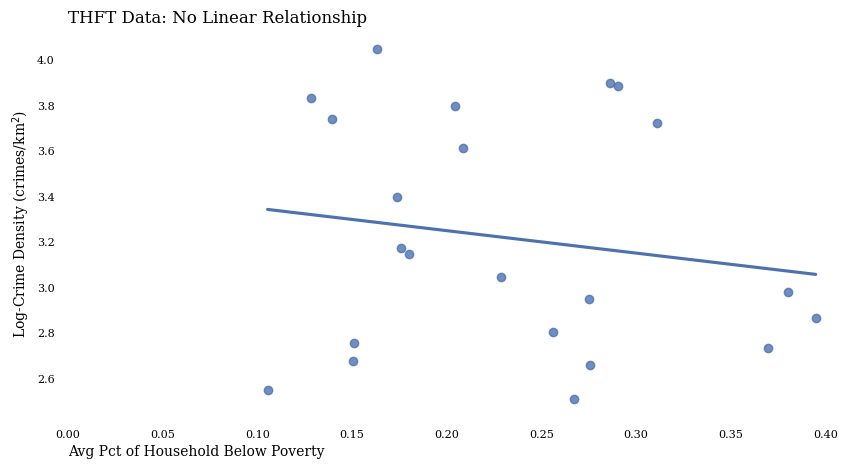

In [8]:
x = 'avg_pct_hh_below_pvty'
y = 'crime_density'
df_model = thft_census.copy()
df_model[y] = np.log(df_model[y]).copy()

sns.regplot(
    
    data=df_model,
    x=x,
    y=y,
    ci=None
)
plt.box(False)
plt.title('THFT Data: No Linear Relationship', loc='left')
plt.xlabel('Avg Pct of Household Below Poverty', loc='left')
plt.ylabel('Log-Crime Density (crimes/km$^2$)')
plt.xlim(0);

plt.savefig(f'{img_path}/fig22.png', dpi=300)

**Domestic Rate vs Avg Income**

When we look at the relation between `domestic_rate` and `avg_per_capita_income`, we get an inverse correlation: when the latter rises, the former decreases. That is to say that, in wealthier regions, domestic violence is lower: an expected result. This can also be verified by that point of view of educational level, since there is an inverse relation between `avg_pct_25_without_hsd` with `avg_per_capita_income`. In this case, we see that `domestic_rate` increases as `avg_pct_25_without_hsd` increases.

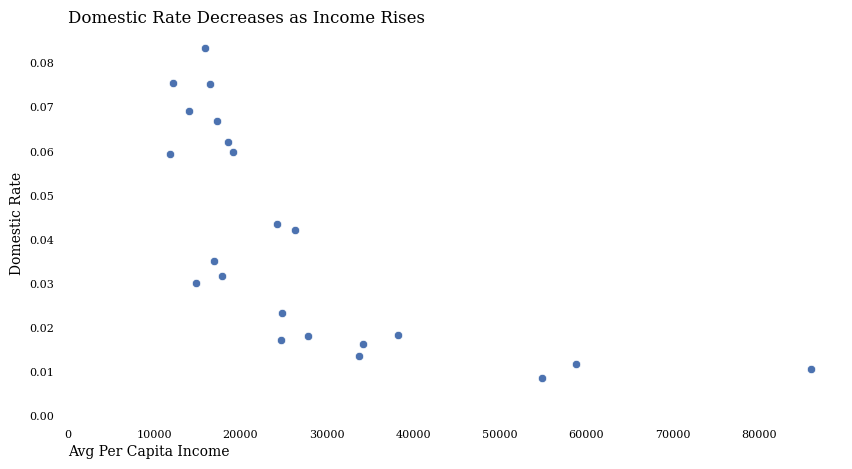

In [9]:
sns.scatterplot(
    data=thft_census,
    x='avg_per_capita_income',
    y='domestic_rate',
)
plt.box(False)
plt.title('Domestic Rate Decreases as Income Rises', loc='left')
plt.xlabel('Avg Per Capita Income', loc='left')
plt.ylabel('Domestic Rate')
plt.xlim(0)
plt.ylim(0);

plt.savefig(f'{img_path}/fig23.png', dpi=300)

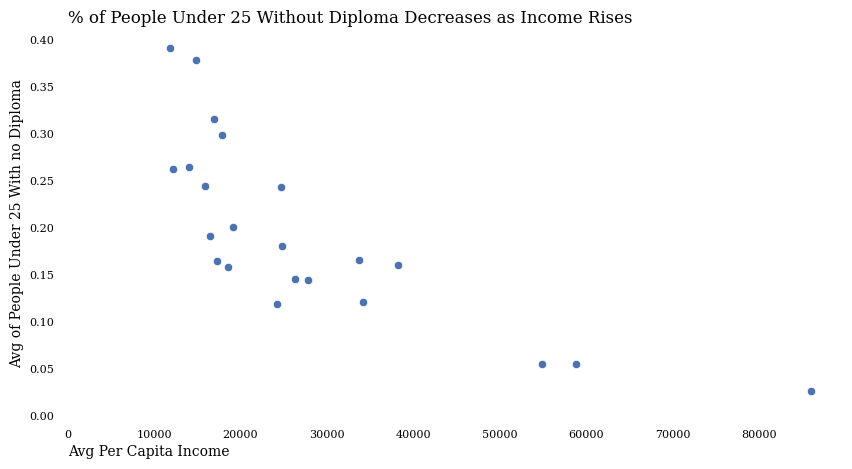

In [10]:
sns.scatterplot(
    data=thft_census,
    x='avg_per_capita_income',
    y='avg_pct_25_without_hsd',
)
plt.box(False)
plt.title('% of People Under 25 Without Diploma Decreases as Income Rises', loc='left')
plt.xlabel('Avg Per Capita Income', loc='left')
plt.ylabel('Avg of People Under 25 With no Diploma')
plt.xlim(0)
plt.ylim(0);

plt.savefig(f'{img_path}/fig24.png', dpi=300)

### Temporal Features: THFT
To make our analysis dynamic and time sensitive, we consider rolling statistics, like moving averages. Several time intervals (windows) were considered (7, 14, 30, 45, 90) and the only one that yields satisfying results, while maintaing its corresponding correlation matrix within $[-0.6, 0.6]$, is the 7-day window.

In [11]:
crime = 'THFT'

# grouping features by district and date, for THFT crime
# calculating total number of occurrences per district per date
# and its corresponding domestic and arrest rates
thft_df = f.grp_features(df_crime, 'district', crime)

print('Grouping the features by district and date for THFT crime...')
display(thft_df.head())

print('Calculating total per average community area and crime density...')

thft_df['avg_count_cm_area'] = thft_df['count'] / thft_df['avg_cm_area']  # counts per avg km2 of cm area
thft_df['avg_drate_cm_area'] = thft_df['domestic_rate'] / thft_df['avg_cm_area']  # domestic rate per avg km2 of cm area
thft_df['avg_arate_cm_area'] = thft_df['arrest_rate'] / thft_df['avg_cm_area']  # arrest rate per avg km2 of cm area
thft_df['avg_crime_density'] = thft_df['count'] / thft_df['avg_total_cm_area']  # counts per avg total covered

thft_df = thft_df.drop(
    columns=['avg_cm_area', 'avg_total_cm_area']
)

display(thft_df.head())

print('Calculating the moving averages...')
rolling_thft7 = f.rolling_grp(thft_df, 7, prefix='THFT')\
    .dropna(axis=0, how='any')

display(rolling_thft7.head(10))

Grouping the features by district and date for THFT crime...


,district,count,domestic_rate,arrest_rate,avg_dist,avg_max_dist,avg_cm_area,avg_cm_len,avg_total_cm_area,avg_total_cm_len,avg_hardship_index
date,,,,,,,,,,,
2022-01-01,1,17,0.000000,0.058824,2.312907,20.922946,69.513587,42.99766,486.595108,300.983622,7.235294
2022-01-02,1,24,0.000000,0.041667,1.742854,20.334184,69.513587,42.99766,486.595108,300.983622,5.833333
2022-01-03,1,22,0.045455,0.136364,1.743103,20.354778,69.513587,42.99766,486.595108,300.983622,6.636364
2022-01-04,1,29,0.000000,0.103448,1.871199,20.410099,69.513587,42.99766,486.595108,300.983622,7.413793
2022-01-05,1,9,0.000000,0.111111,1.821512,20.448050,69.513587,42.99766,486.595108,300.983622,9.666667


Calculating total per average community area and crime density...


,district,count,domestic_rate,arrest_rate,avg_dist,avg_max_dist,avg_cm_len,avg_total_cm_len,avg_hardship_index,avg_count_cm_area,avg_drate_cm_area,avg_arate_cm_area,avg_crime_density
date,,,,,,,,,,,,,
2022-01-01,1,17,0.000000,0.058824,2.312907,20.922946,42.99766,300.983622,7.235294,0.244557,0.000000,0.000846,0.034937
2022-01-02,1,24,0.000000,0.041667,1.742854,20.334184,42.99766,300.983622,5.833333,0.345256,0.000000,0.000599,0.049322
2022-01-03,1,22,0.045455,0.136364,1.743103,20.354778,42.99766,300.983622,6.636364,0.316485,0.000654,0.001962,0.045212
2022-01-04,1,29,0.000000,0.103448,1.871199,20.410099,42.99766,300.983622,7.413793,0.417185,0.000000,0.001488,0.059598
2022-01-05,1,9,0.000000,0.111111,1.821512,20.448050,42.99766,300.983622,9.666667,0.129471,0.000000,0.001598,0.018496


Calculating the moving averages...


,district,date,THFT_RollAvg7,THFT_RollDRate7,THFT_RollARate7,THFT_RollAvgDist7,THFT_RollAvgMaxDist7,THFT_RollAvgCMLen7,THFT_RollAvgLen7,THFT_RollAvgHardship7,THFT_RollAvgCountCMArea7,THFT_RollAvgDRateCMArea7,THFT_RollAvgARateCMArea7,THFT_RollAvgDensity7
6,1,2022-01-07,19.857143,0.014897,0.084896,1.903388,20.461787,42.99766,300.983622,7.488758,0.285658,0.000214,0.001221,0.040808
7,1,2022-01-08,19.428571,0.014897,0.086696,1.800941,20.327490,42.99766,300.983622,7.659226,0.279493,0.000214,0.001247,0.039928
8,1,2022-01-09,17.428571,0.014897,0.095030,1.854355,20.408325,42.99766,300.983622,7.483036,0.250722,0.000214,0.001367,0.035817
9,1,2022-01-10,15.571429,0.008403,0.091422,1.858420,20.377908,42.99766,300.983622,7.408000,0.224006,0.000121,0.001315,0.032001
10,1,2022-01-11,14.714286,0.008403,0.076644,1.887670,20.424314,42.99766,300.983622,7.150128,0.211675,0.000121,0.001103,0.030239
11,1,2022-01-12,16.428571,0.015206,0.081179,1.892164,20.405033,42.99766,300.983622,7.578700,0.236336,0.000219,0.001168,0.033762
12,1,2022-01-13,17.714286,0.006803,0.081179,1.924471,20.438221,42.99766,300.983622,7.824337,0.254832,0.000098,0.001168,0.036405
13,1,2022-01-14,18.285714,0.006803,0.066485,1.901072,20.473409,42.99766,300.983622,7.206105,0.263052,0.000098,0.000956,0.037579
14,1,2022-01-15,18.285714,0.006803,0.066485,1.895464,20.467858,42.99766,300.983622,7.808146,0.263052,0.000098,0.000956,0.037579
15,1,2022-01-16,19.857143,0.006803,0.065805,1.874668,20.437613,42.99766,300.983622,7.933316,0.285658,0.000098,0.000947,0.040808


### Training and OOT Samples

In [12]:
# training sample: data before 2025
train_thft = rolling_thft7.query('date < "2025-01-01"').copy()

# out of time sample: data from 2025 onwards
oot_thft = rolling_thft7.query('date >= "2025-01-01"').copy()

In [13]:
train_thft.to_csv(f'{gld_path}/train_thft.csv', index=False)
oot_thft.to_csv(f'{gld_path}/oot_thft.csv', index=False)

### Features

In [14]:
train_thft = pd.read_csv(f'{gld_path}/train_thft.csv')
oot_thft = pd.read_csv(f'{gld_path}/oot_thft.csv')

In [23]:
grp = 'THFT'
grp_features = [
    f'{grp}_RollAvg7',
    f'{grp}_RollDRate7',
    f'{grp}_RollARate7',
    f'{grp}_RollAvgDist7',
    f'{grp}_RollAvgMaxDist7',
    f'{grp}_RollAvgDensity7'
]
cm_features = [
    f'{grp}_RollAvgCMLen7',
    f'{grp}_RollAvgLen7',
    f'{grp}_RollAvgHardship7',
    f'{grp}_RollAvgCountCMArea7',
    f'{grp}_RollAvgDRateCMArea7',
    f'{grp}_RollAvgARateCMArea7'
]
features_list = grp_features + cm_features


features_raw_thft = train_thft[features_list].copy()
features_thft = features_raw_thft.dropna().reset_index(drop=True).copy()

features_thft.head()

,THFT_RollAvg7,THFT_RollDRate7,THFT_RollARate7,THFT_RollAvgDist7,THFT_RollAvgMaxDist7,THFT_RollAvgDensity7,THFT_RollAvgCMLen7,THFT_RollAvgLen7,THFT_RollAvgHardship7,THFT_RollAvgCountCMArea7,THFT_RollAvgDRateCMArea7,THFT_RollAvgARateCMArea7
0,19.857143,0.014897,0.084896,1.903388,20.461787,0.040808,42.99766,300.983622,7.488758,0.285658,0.000214,0.001221
1,19.428571,0.014897,0.086696,1.800941,20.327490,0.039928,42.99766,300.983622,7.659226,0.279493,0.000214,0.001247
2,17.428571,0.014897,0.095030,1.854355,20.408325,0.035817,42.99766,300.983622,7.483036,0.250722,0.000214,0.001367
3,15.571429,0.008403,0.091422,1.858420,20.377908,0.032001,42.99766,300.983622,7.408000,0.224006,0.000121,0.001315
4,14.714286,0.008403,0.076644,1.887670,20.424314,0.030239,42.99766,300.983622,7.150128,0.211675,0.000121,0.001103


Anaylising the `features_thft` dataset, we observe some variables with high correlation. Regarding its distributions, we see, more interestingly, via the histogram-boxplot figure, that

- `THFT_RollAvg7` is modal around 10, showing that a typical district sees around 10 occurrences in a 7 day window, with outliers above 30, indicating highly aggressive district(s) (crime surges?)
- `THFT_RollDRate7` is highly concentrated at 0, indicating that most theft-related occurrences in a 7 day window are not domestic; nonetheless, we have its median around 0.04, which is to be contrasted with the `ASLT_RollDRate7`, where its median is around 0.30, being almost ten times greater
- `THFT_RollARate7` has its median around 0.05, being four times less than that of `ASLT_RollARate7`

It is possible to conclude, from the above description, that theft-related occurrences have less arrest and domestic rates than assault-related ones, in a 7 day window, in concordance with our previous testing hypothesis.

In [24]:
print('Pearson correlation:')
display(features_thft.corr(method='pearson'))

features_thft = features_thft.drop(
    columns=[
        'THFT_RollAvgLen7',
        'THFT_RollAvgCountCMArea7',
        'THFT_RollAvgDRateCMArea7',
        'THFT_RollAvgARateCMArea7'
    ]
)

Pearson correlation:


,THFT_RollAvg7,THFT_RollDRate7,THFT_RollARate7,THFT_RollAvgDist7,THFT_RollAvgMaxDist7,THFT_RollAvgDensity7,THFT_RollAvgCMLen7,THFT_RollAvgLen7,THFT_RollAvgHardship7,THFT_RollAvgCountCMArea7,THFT_RollAvgDRateCMArea7,THFT_RollAvgARateCMArea7
THFT_RollAvg7,1.000000,-0.369314,0.064368,0.052025,-0.320973,0.585808,-0.254879,0.170722,-0.477431,0.849870,-0.238918,0.158720
THFT_RollDRate7,-0.369314,1.000000,-0.160822,-0.032690,-0.008603,-0.221245,0.244506,-0.105901,0.575836,-0.366924,0.857626,-0.269593
THFT_RollARate7,0.064368,-0.160822,1.000000,-0.159267,-0.105799,0.141234,0.020279,-0.133350,-0.217059,0.019023,-0.196284,0.910289
THFT_RollAvgDist7,0.052025,-0.032690,-0.159267,1.000000,0.282531,-0.412615,-0.069244,0.789357,0.003524,0.045949,0.049075,-0.132321
THFT_RollAvgMaxDist7,-0.320973,-0.008603,-0.105799,0.282531,1.000000,-0.301190,0.051653,0.192639,-0.184806,-0.327094,-0.043762,-0.107765
THFT_RollAvgDensity7,0.585808,-0.221245,0.141234,-0.412615,-0.301190,1.000000,-0.043722,-0.589055,-0.441894,0.659017,-0.127972,0.268219
THFT_RollAvgCMLen7,-0.254879,0.244506,0.020279,-0.069244,0.051653,-0.043722,1.000000,-0.148076,0.159348,-0.558651,-0.161743,-0.278376
THFT_RollAvgLen7,0.170722,-0.105901,-0.133350,0.789357,0.192639,-0.589055,-0.148076,1.000000,0.030443,0.047717,-0.045959,-0.148881
THFT_RollAvgHardship7,-0.477431,0.575836,-0.217059,0.003524,-0.184806,-0.441894,0.159348,0.030443,1.000000,-0.473594,0.447228,-0.349120
THFT_RollAvgCountCMArea7,0.849870,-0.366924,0.019023,0.045949,-0.327094,0.659017,-0.558651,0.047717,-0.473594,1.000000,-0.061711,0.258728


When looking at the outliers, we disregard `cm_features` as they do not reflect occurrences data.

In [25]:
features_outliers = features_thft[grp_features].copy()

s = 1.5
q1 = features_outliers.quantile(0.25)
q3 = features_outliers.quantile(0.75)
iqr = q3 - q1

iqr_lower = q1 - s * iqr
iqr_upper = q3 + s * iqr

outliers = (
    (features_outliers < iqr_lower) | (features_outliers > iqr_upper)
).any(axis=1)

iqr

THFT_RollAvg7           8.142857
THFT_RollDRate7         0.046994
THFT_RollARate7         0.045208
THFT_RollAvgDist7       1.054040
THFT_RollAvgMaxDist7    8.636784
THFT_RollAvgDensity7    0.020665
dtype: float64

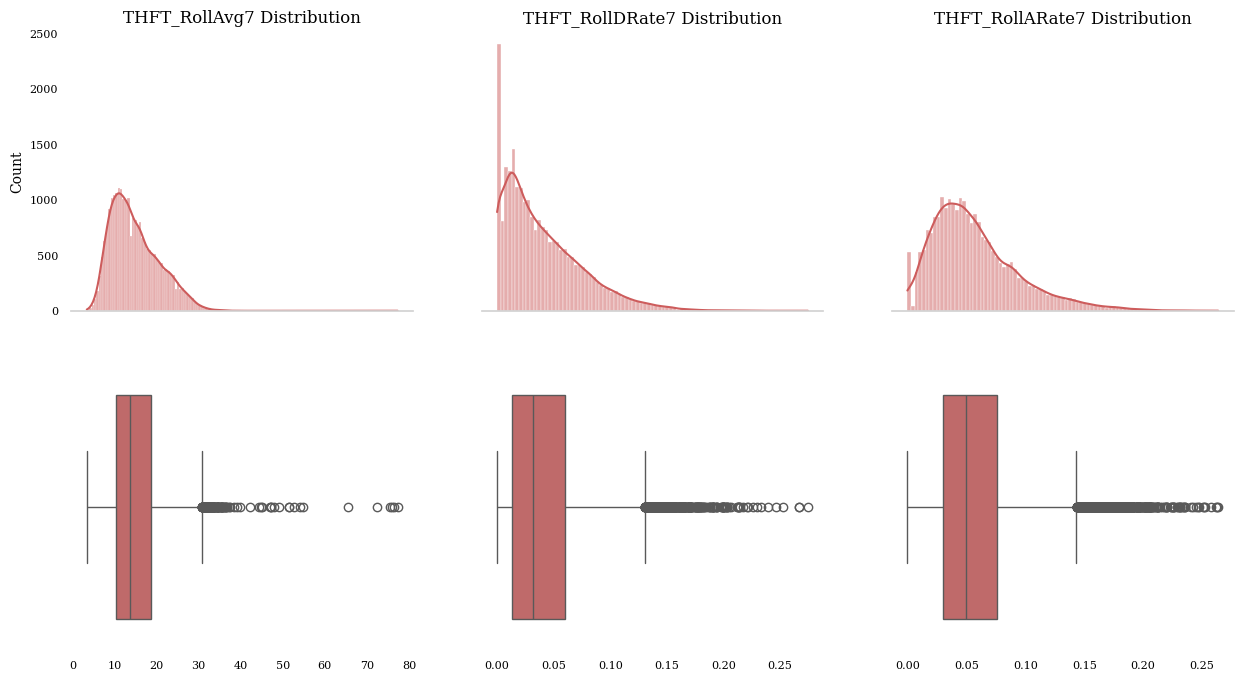

In [26]:
f.gen_paired_hist_box(
    features_thft[[
        f'{grp}_RollAvg7',
        f'{grp}_RollDRate7',
        f'{grp}_RollARate7',
    ]]
)

plt.savefig(f'{img_path}/fig25.png', dpi=300)

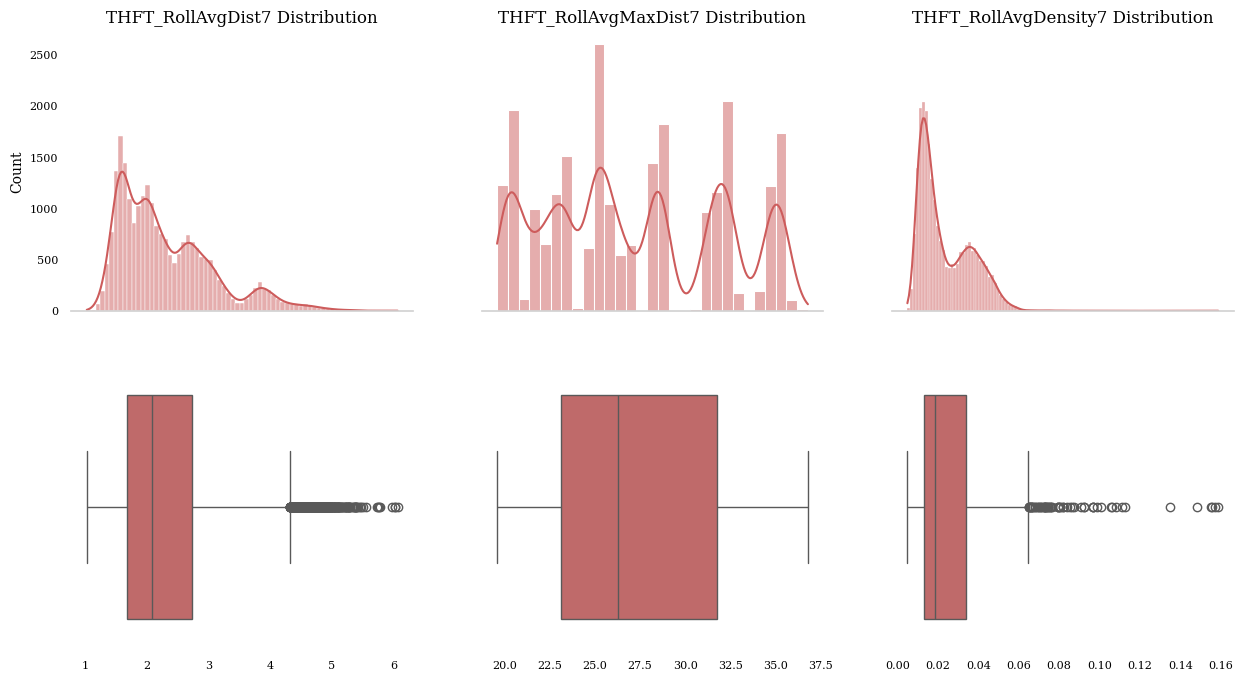

In [27]:
f.gen_paired_hist_box(
    features_thft[[
        f'{grp}_RollAvgDist7',
        f'{grp}_RollAvgMaxDist7',
        f'{grp}_RollAvgDensity7',
    ]]
)

plt.savefig(f'{img_path}/fig26.png', dpi=300)

#### Outliers: THFT
Before going into Machine Learning, caution is adivsed when concerning outliers, since it may compromise the model's performance or even mislead one's interpretation. In our case, it seems unlikely that the outliers arise from errors or low data quality, falling best on the rare occurrences category.

By selecting them onto our dataset, we can analyse them via two interesting point of views: by `date` and by `district`, so as to associate the outliers due to some time or zone event. For instance, when looking at the `date` point of view, where we count the number of districts that are being referred to as outliers in a given date, we observe entries with at most 8 districts, suggesting notorious time periods. Particularly, we emphasize the start of every year.

In [28]:
out_index = features_thft[outliers].index

out_df = train_thft[train_thft.index.isin(out_index)].copy()

# analysing per date: days showing occurrences in at least 4 districts
# (> 10% the total number of districts)
out_df_date = out_df[['date', 'district']]\
    .groupby('date')\
    .agg(count=('district', 'count'))\
    .reset_index()
out_df_date.query('count > 4').head(50)

,date,count
16,2022-01-24,5
17,2022-01-25,5
80,2022-04-01,5
121,2022-05-13,5
142,2022-06-03,5
174,2022-07-07,6
175,2022-07-08,6
176,2022-07-09,5
343,2023-02-16,5
344,2023-02-17,6


From the district-day analysis, we are able to observe hot districts, facing occurrences in at most 481 days, being an average of approximately 1.5 occurrences per day.

In [29]:
# analysing per district: district showing occurrences in at least 50 days
out_df_district = out_df[['date', 'district']]\
    .groupby('district')\
    .agg(count=('date', 'count'))\
    .reset_index()

out_df_district.query('count > 50')

,district,count
0,1,339
4,5,176
6,7,96
9,10,61
10,11,184
13,15,170
14,16,481
16,18,59
17,19,72
18,20,67
